# E-commerce Customer Returns — Exploratory Data Analysis (EDA)

**Dataset:** `tableau_ready.csv` — 19,940 cleaned rows x 26 columns

**Goal of this notebook:** Move beyond "what does the data look like" into **"what patterns explain returns behavior"** — the core question driving this project.

**Structure:**
1. Univariate Analysis (numeric + categorical distributions)
2. Target Variable Deep Dive (`returned`)
3. Bivariate Analysis — each feature vs. `returned`, backed by a statistical test
4. Multivariate Analysis (interactions between 2+ features)
5. Return Reason Analysis
6. Correlation Analysis
7. Summary of Statistically Validated Insights → feeding into Business Recommendations


## 1. Setup & Data Loading

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway, pointbiserialr

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('tableau_ready.csv')
print(f"Shape: {df.shape}")
df.head(3)


Shape: (19940, 26)


,order_id,customer_id,customer_age,customer_gender,product_category,product_price,order_quantity,discount_percent,payment_method,shipping_method,delivery_time_days,delivery_delay_days,customer_rating,past_return_rate,return_reason,returned,is_extreme_delivery_delay,is_high_value_product,is_bulk_order,returned_flag,age_group,price_band,delivery_delay_bucket,rating_band,past_return_band,order_value
0,ORD010306,CUST04587,43,Female,Books,28.70,2,18.59,Cash on Delivery,Express,4.0,1,4.4,0.149,Size/fit issue,Yes,False,False,False,1,36-45,$25-50,1-2 days late,4-5 (Great),Med (10-20%),57.40
1,ORD012251,CUST02016,33,Male,Fashion,66.36,3,3.98,Cash on Delivery,Standard,4.0,-1,4.1,0.191,Not Returned,No,False,False,False,0,26-35,$50-100,On-time/Early,4-5 (Great),Med (10-20%),199.08
2,ORD004778,CUST01696,33,Male,Electronics,183.54,2,33.38,Wallet,Express,4.0,1,4.0,0.015,Not Returned,No,False,False,False,0,26-35,$100-200,1-2 days late,3-4 (Good),Low (<10%),367.08


## 2. Univariate Analysis — Numeric Variables

**Question we're asking:** What does the "typical" order look like on its own terms — before we relate
anything to returns? Understanding baseline shape (skew, spread, concentration) tells us which
variables need transformation before statistical testing, and which are naturally suited to binning.


In [37]:
numeric_cols = ['customer_age', 'product_price', 'order_quantity', 'discount_percent',
                'delivery_time_days', 'delivery_delay_days', 'customer_rating',
                'past_return_rate', 'order_value']

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
customer_age,19940.0,36.533250,11.322874,18.00,28.000,36.000,45.0000,76.000
product_price,19940.0,143.970099,216.822280,6.72,44.770,82.755,166.3775,6373.070
order_quantity,19940.0,2.203962,3.107931,1.00,1.000,2.000,3.0000,60.000
discount_percent,19940.0,19.015756,11.598354,0.00,10.300,17.340,25.8400,100.000
delivery_time_days,19940.0,5.021966,3.604712,1.00,3.000,5.000,6.0000,61.000
delivery_delay_days,19940.0,1.190471,2.822717,-1.00,0.000,1.000,2.0000,46.000
customer_rating,19940.0,3.873325,0.657071,1.00,3.500,3.900,4.3000,5.000
past_return_rate,19940.0,0.170753,0.133036,0.00,0.065,0.140,0.2460,0.744
order_value,19940.0,313.704617,745.834995,6.72,69.210,142.985,316.3725,29661.120


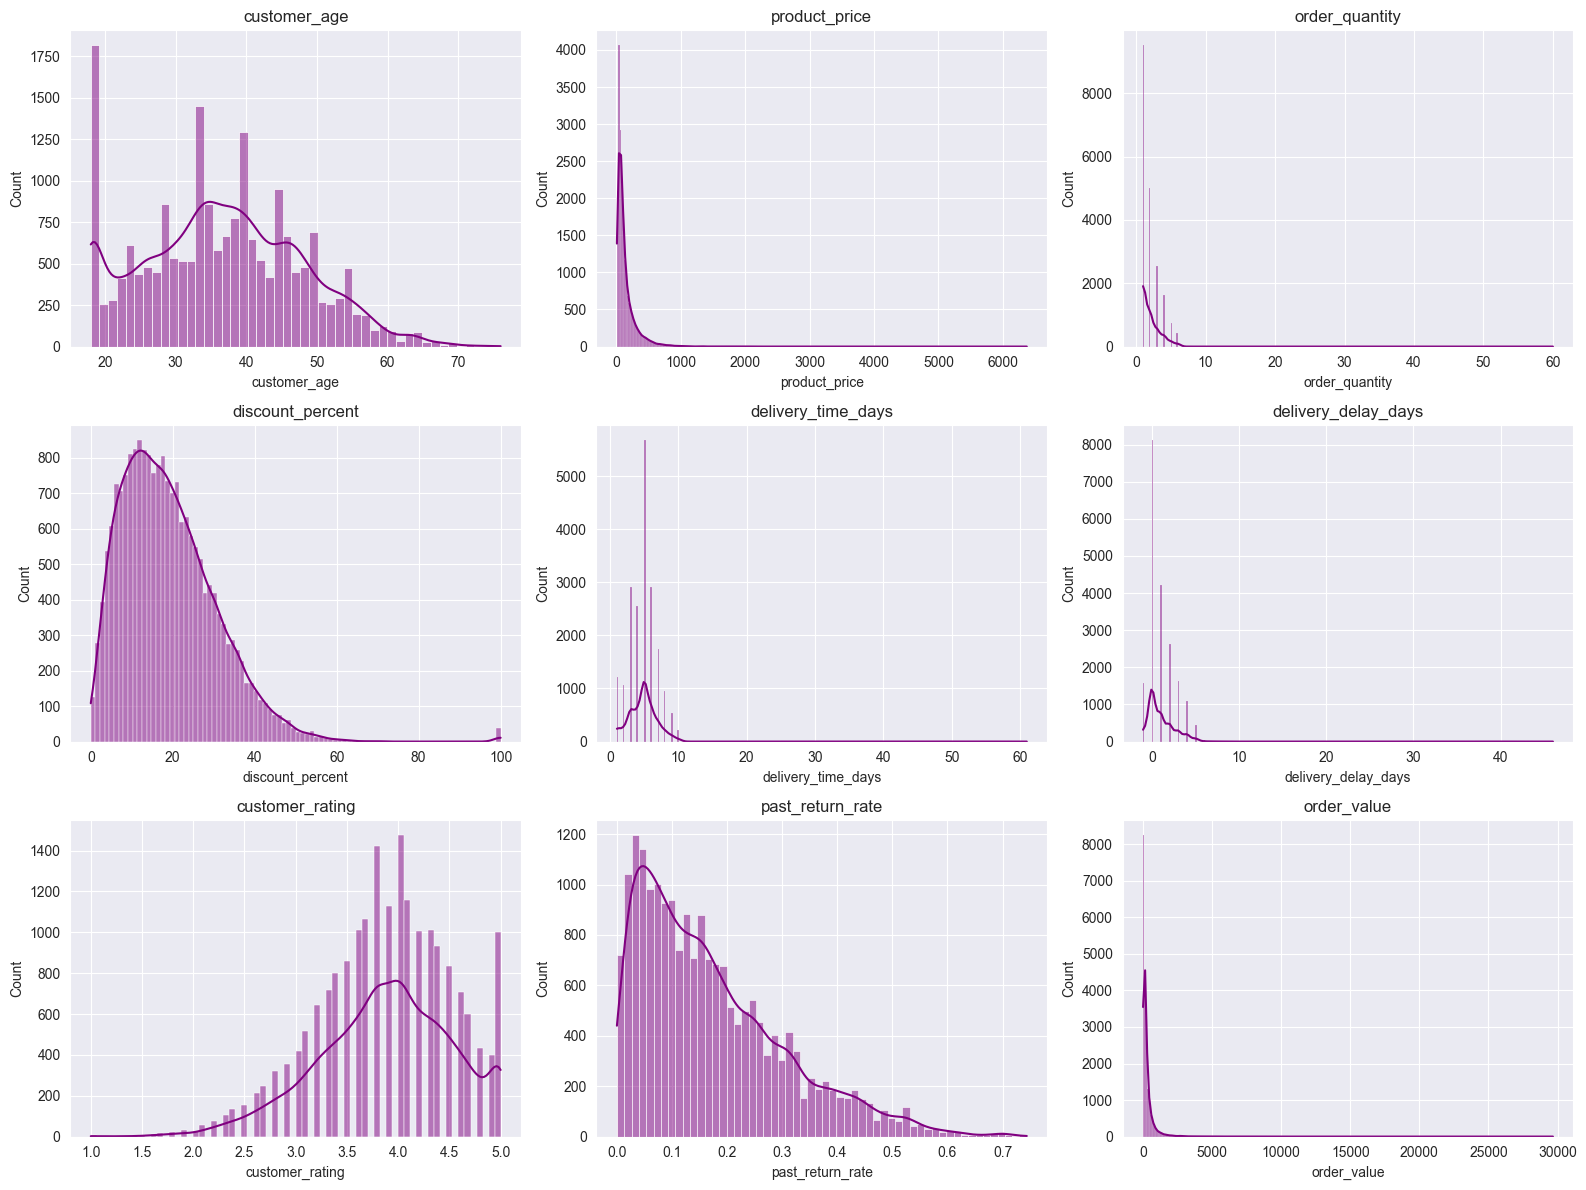

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='purple')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretation:**
- `product_price` and `order_value` are right-skewed — most orders are low-to-mid value with a long tail
  of high-value purchases.
- `customer_rating` clusters around 3.5–4.5, suggesting most customers are moderately satisfied — ratings
  near the extremes (1 or 5) are comparatively rare.
- `past_return_rate` is concentrated below 0.3, with a long right tail — a small segment of customers/products
  carry disproportionately high return history, worth isolating in later segmentation.
- `delivery_delay_days` centers near 0–2 days.


## 3. Univariate Analysis — Categorical Variables

**Question we're asking:** Which categories dominate the dataset? An imbalanced category (e.g., one
`product_category` making up 60% of orders) changes how we interpret any later "return rate by category"
comparison — small categories will have noisier estimates.


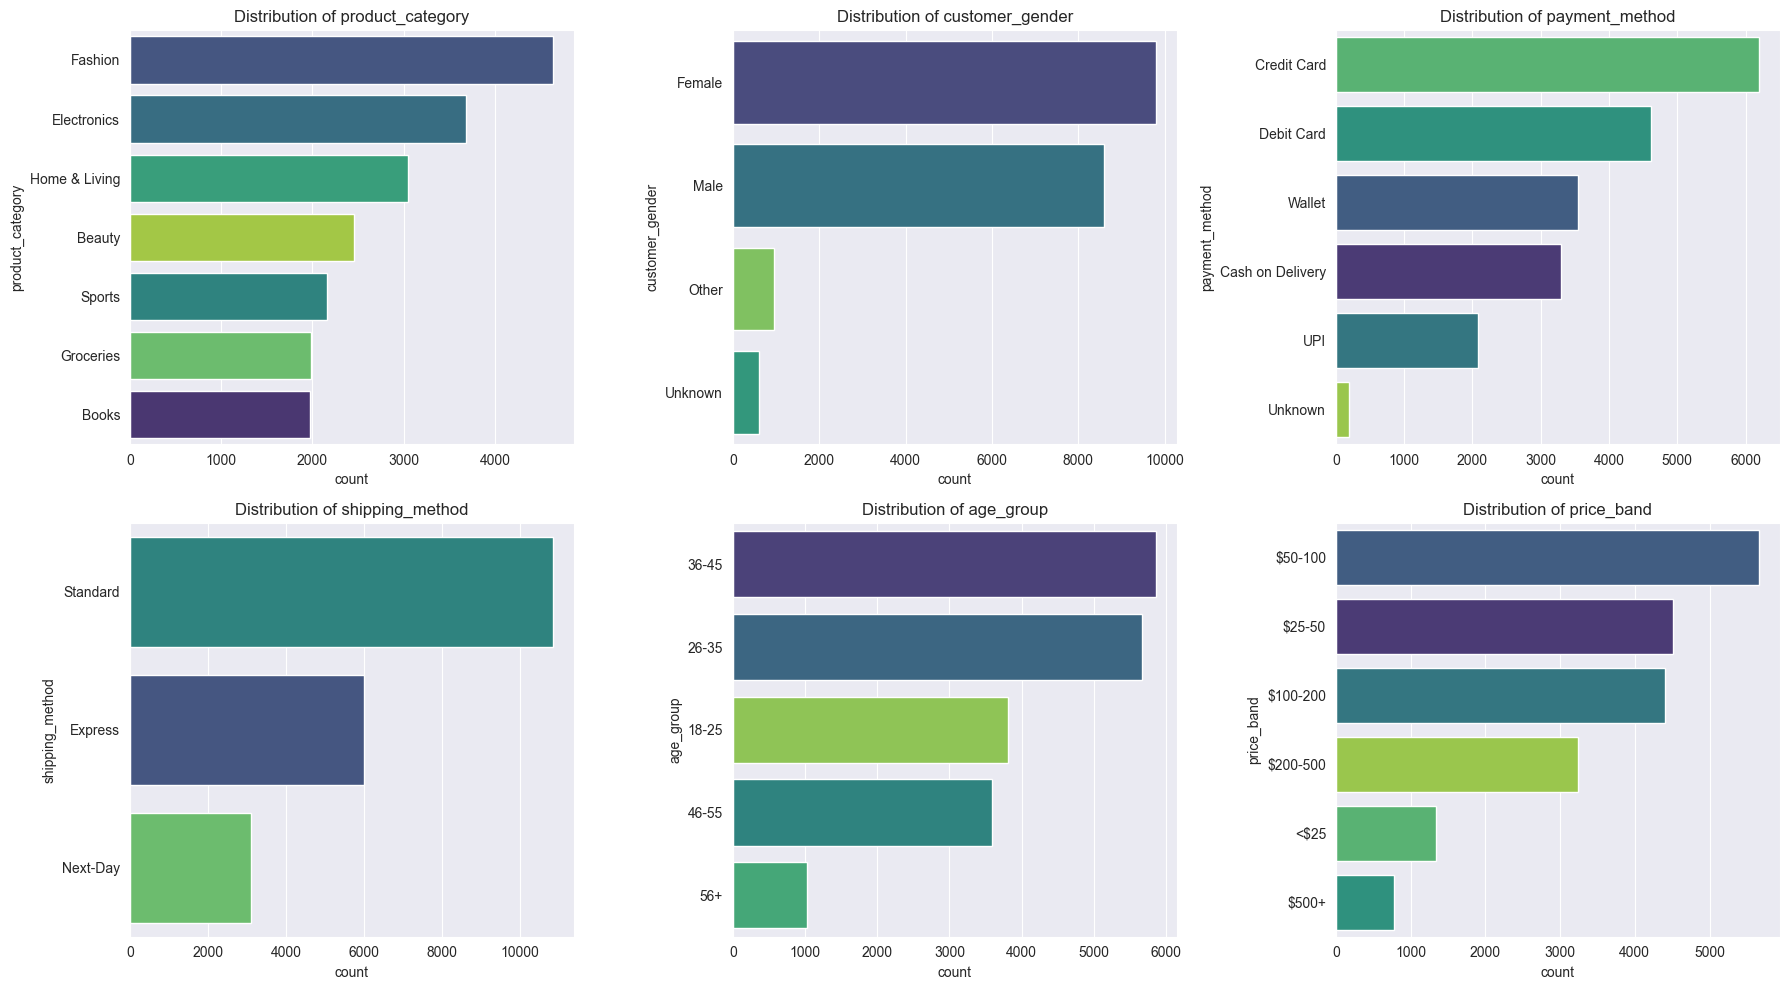

In [45]:
categorical_cols = ['product_category', 'customer_gender', 'payment_method',
                    'shipping_method', 'age_group', 'price_band']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, palette='viridis',legend=False,hue=col)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


**Interpretation:** Note which categories are under-represented (fewer than ~500 rows) — return rate
comparisons for these should be treated with caution due to smaller sample size, and any chi-square test
including them should check expected cell counts (Cochran's rule: expected count ≥5 per cell).


## 4. Target Variable Deep Dive — `returned`

**Question we're asking:** How imbalanced is our target, and does that change how we should interpret
"return rate" percentages later? A 20/80 split (common in returns data) means small percentage-point
differences (e.g., 18% vs 22%) can still be practically meaningful, but raw counts can mislead casual
readers of a dashboard.


returned
No     80.421264
Yes    19.578736
Name: proportion, dtype: float64


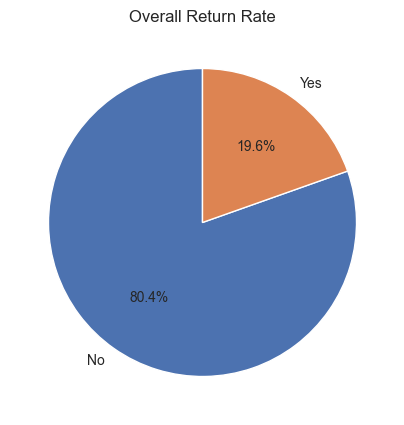

In [46]:
return_counts = df['returned'].value_counts()
return_pct = df['returned'].value_counts(normalize=True) * 100
print(return_pct)

plt.figure(figsize=(5, 5))
plt.pie(return_counts, labels=return_counts.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Overall Return Rate')
plt.show()


**Interpretation:**  — 19.5 % Returns -> roughly 1 in 5 orders gets returned. This
baseline rate is the benchmark every subsequent segment comparison should be measured against: a segment
above this baseline is a "problem area," a segment meaningfully below it is a "healthy segment" worth
understanding and replicating. 


## 5. Bivariate Analysis — Return Rate by Product Category

**Question we're asking:** Do certain product categories drive disproportionately more returns? This is
one of the most actionable questions for the business — it directly informs category-level return policy,
QA investment, and supplier conversations.

**Statistical validation:** Chi-square test of independence between `product_category` and `returned`.


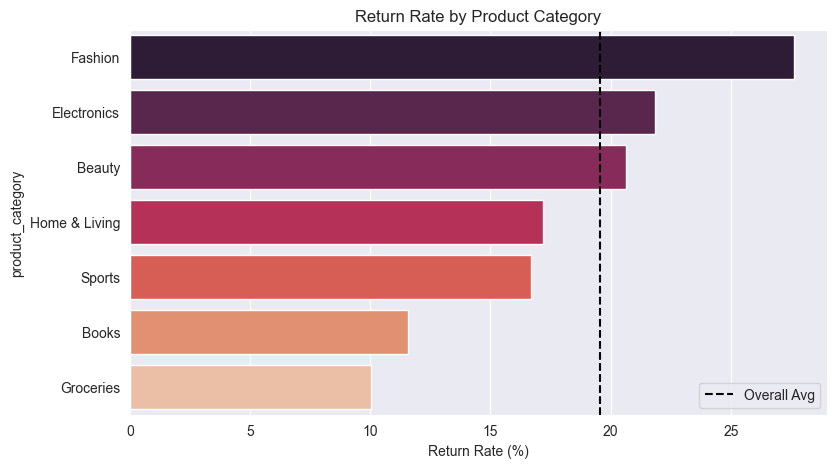

In [48]:
cat_return = (df.groupby('product_category')['returned']
                .apply(lambda x: (x == 'Yes').mean() * 100)
                .sort_values(ascending=False))

plt.figure(figsize=(9, 5))
sns.barplot(x=cat_return.values, y=cat_return.index, palette='rocket',hue=cat_return.index,legend=False)
plt.xlabel('Return Rate (%)')
plt.title('Return Rate by Product Category')
plt.axvline(df['returned_flag'].mean()*100, color='black', linestyle='--', label='Overall Avg')
plt.legend()
plt.show()


In [49]:
contingency = pd.crosstab(df['product_category'], df['returned'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.5f}")
print(f"Degrees of freedom: {dof}")


Chi-square statistic: 421.72
p-value: 0.00000
Degrees of freedom: 6


**Interpretation:** Here, p < 0.05, `product_category` and `returned` are
NOT independent — i.e., return likelihood genuinely differs by category, and this isn't due to random
chance. Fashion,Electronics and Beauty are the worst categories as their returns are highest. 

## 6. Bivariate Analysis — Return Rate by Delivery Delay

**Question we're asking:** Does a late delivery make a customer more likely to return the product — even
if the product itself is fine? This tests whether returns are being driven by **logistics failure** rather
than **product quality failure** — a critical distinction for where the business should invest to reduce
returns.

**Statistical validation:** Chi-square test between `delivery_delay_bucket` and `returned`.


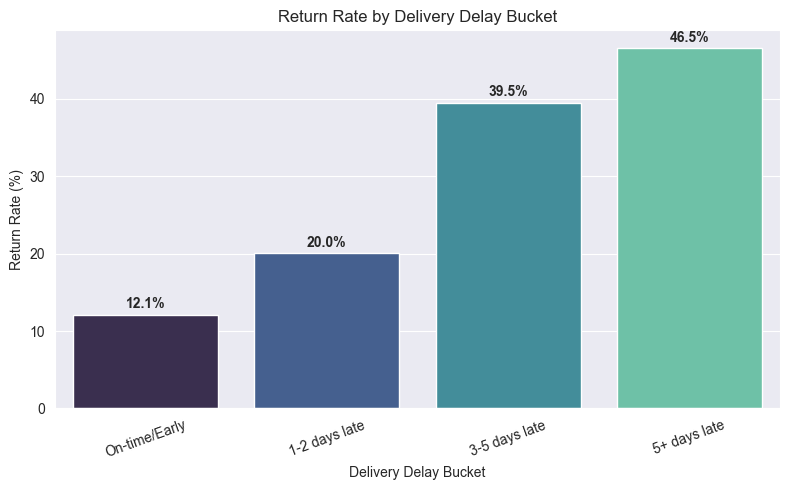

In [53]:
delay_return = (
    df.groupby('delivery_delay_bucket')['returned']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reindex(df['delivery_delay_bucket'].value_counts().index)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=delay_return.index,
    y=delay_return.values,
    palette="mako",
    hue=delay_return.index,
    legend=False
)

# Add percentage labels on top of each bar
for i, value in enumerate(delay_return.values):
    ax.text(
        i,                  # x-position
        value + 0.5,        # y-position (slightly above bar)
        f"{value:.1f}%",    # Text
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.ylabel("Return Rate (%)")
plt.xlabel("Delivery Delay Bucket")
plt.title("Return Rate by Delivery Delay Bucket")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [52]:
contingency_delay = pd.crosstab(df['delivery_delay_bucket'], df['returned'])
chi2, p, dof, expected = chi2_contingency(contingency_delay)
print(f"Chi-square statistic: {chi2:.2f}  |  p-value: {p:.5f}")


Chi-square statistic: 1235.95  |  p-value: 0.00000


**Interpretation:**  46.5 % for more than 5+ days delay and 39.5 % return rate for 3to 5 days delay — a rising return rate as delay increases.

This strongly suggest logistics-driven returns, meaning improving delivery reliability could directly cut
return volume — a very actionable, cost-linked recommendation. If the trend reverses at extreme delay
buckets (small sample), call that out as a low-confidence tail rather than a real effect.


## 7. Bivariate Analysis — Return Rate by Price Band

**Question we're asking:** Are expensive products returned more or less often than cheap ones? Two
competing hypotheses exist here: (a) expensive items get more scrutiny at delivery → higher returns, or
(b) expensive items are considered purchases → lower returns. This chart+test settles which pattern holds
in this data.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40692\118305864.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_return.index, y=price_return.values, palette='flare')


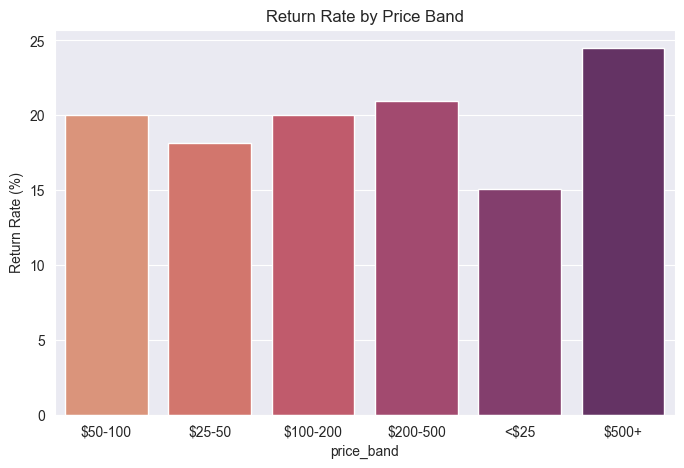

In [54]:
price_return = (df.groupby('price_band')['returned']
                  .apply(lambda x: (x == 'Yes').mean() * 100)
                  .reindex(df['price_band'].value_counts().index))

plt.figure(figsize=(8, 5))
sns.barplot(x=price_return.index, y=price_return.values, palette='flare')
plt.ylabel('Return Rate (%)')
plt.title('Return Rate by Price Band')
plt.show()


In [55]:
contingency_price = pd.crosstab(df['price_band'], df['returned'])
chi2, p, dof, expected = chi2_contingency(contingency_price)
print(f"Chi-square statistic: {chi2:.2f}  |  p-value: {p:.5f}")


Chi-square statistic: 40.36  |  p-value: 0.00000


**Interpretation:** if high-value items return more, that's a bigger revenue risk per return
and may justify stricter packaging/QA for that band specifically .


## 8. Bivariate Analysis — Discount Percent vs Returns

**Question we're asking:** Are heavily discounted products bought more impulsively and therefore returned
more often? This tests whether aggressive discounting/promotions are quietly inflating the return rate.

**Statistical validation:** Independent-samples t-test comparing mean `discount_percent` between returned
vs. non-returned orders.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40692\1682220194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='returned', y='discount_percent', palette='Set2')


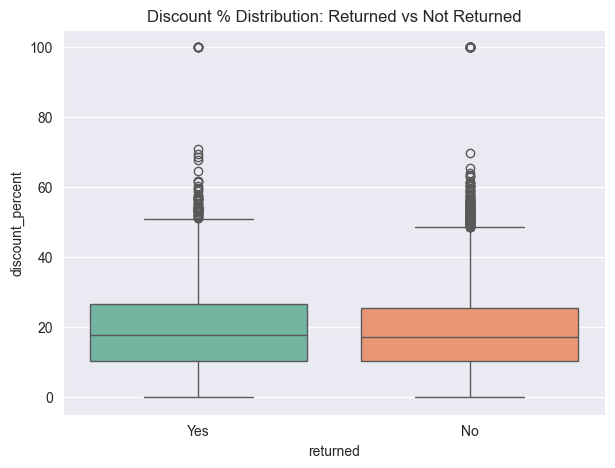

In [56]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='returned', y='discount_percent', palette='Set2')
plt.title('Discount % Distribution: Returned vs Not Returned')
plt.show()


In [57]:
returned_disc = df.loc[df['returned'] == 'Yes', 'discount_percent']
not_returned_disc = df.loc[df['returned'] == 'No', 'discount_percent']

t_stat, p_val = ttest_ind(returned_disc, not_returned_disc, equal_var=False)
print(f"Mean discount (Returned): {returned_disc.mean():.2f}%")
print(f"Mean discount (Not Returned): {not_returned_disc.mean():.2f}%")
print(f"T-statistic: {t_stat:.3f}  |  p-value: {p_val:.5f}")


Mean discount (Returned): 19.65%
Mean discount (Not Returned): 18.86%
T-statistic: 3.679  |  p-value: 0.00024


**Interpretation:**  p < 0.05 but returned orders do not show a meaningfully
higher mean discount, this do not supports the "impulsive discount-driven purchase" hypothesis — a signal for
marketing to reconsider steep-discount promotions on categories already prone to high returns.


## 9. Bivariate Analysis — Customer Rating vs Returns

**Question we're asking:** Do customers who eventually return the product tend to leave a lower product
rating? This checks whether `customer_rating` can act as an early-warning signal for returns (useful for
proactive intervention before a return is even filed).


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40692\1995413193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='returned', y='customer_rating', palette='coolwarm')


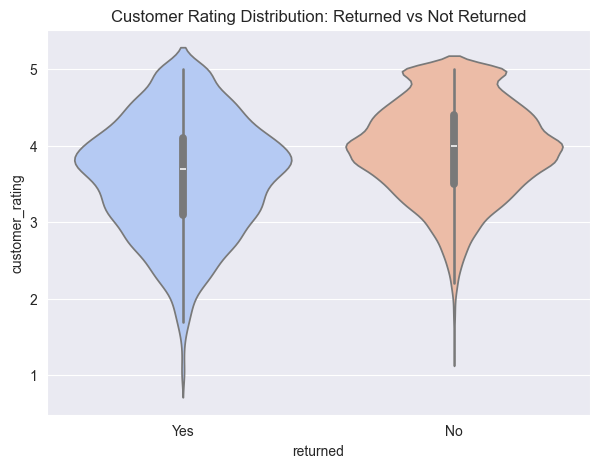

In [58]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='returned', y='customer_rating', palette='coolwarm')
plt.title('Customer Rating Distribution: Returned vs Not Returned')
plt.show()


In [59]:
returned_rating = df.loc[df['returned'] == 'Yes', 'customer_rating']
not_returned_rating = df.loc[df['returned'] == 'No', 'customer_rating']

t_stat, p_val = ttest_ind(returned_rating, not_returned_rating, equal_var=False)
print(f"Mean rating (Returned): {returned_rating.mean():.2f}")
print(f"Mean rating (Not Returned): {not_returned_rating.mean():.2f}")
print(f"T-statistic: {t_stat:.3f}  |  p-value: {p_val:.5f}")


Mean rating (Returned): 3.59
Mean rating (Not Returned): 3.94
T-statistic: -27.314  |  p-value: 0.00000


**Interpretation:** Not a significantly lower average rating among returned
orders. This do not validate using `customer_rating` as a leading indicator; But still we can consider flagging orders with
low ratings for proactive customer service outreach before a formal return request.


## 10. Bivariate Analysis — Past Return Rate vs Current Return

**Question we're asking:** Is `past_return_rate` actually predictive of the *current* order being
returned — i.e., is "once a returner, often a returner" true in this data? This is likely one of the
strongest predictors available, and worth confirming statistically rather than assuming.

**Statistical validation:** Point-biserial correlation between `past_return_rate` (continuous) and
`returned_flag` (binary).


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40692\2490855285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='returned', y='past_return_rate', palette='Set3')


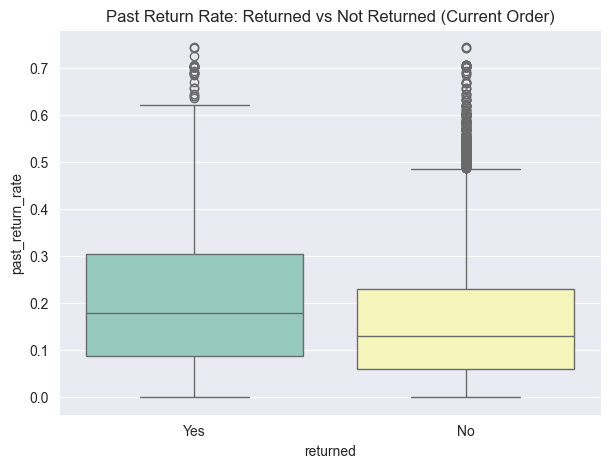

In [60]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='returned', y='past_return_rate', palette='Set3')
plt.title('Past Return Rate: Returned vs Not Returned (Current Order)')
plt.show()


In [61]:
corr, p_val = pointbiserialr(df['returned_flag'], df['past_return_rate'])
print(f"Point-biserial correlation: {corr:.3f}  |  p-value: {p_val:.5f}")


Point-biserial correlation: 0.138  |  p-value: 0.00000


**Interpretation:**  a positive, statistically significant correlation
confirms `past_return_rate` as a strong, quantifiable predictor. This is the single most useful field for
building a "high-risk-of-return" customer segment for proactive retention/QA measures.


## 11. Bivariate Analysis — Return Rate by Payment Method

**Question we're asking:** Does how a customer pays correlate with return likelihood (e.g., Cash on
Delivery orders — which involve no upfront commitment — being returned more than prepaid methods)?


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40692\1182815895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_return.values, y=payment_return.index, palette='crest')


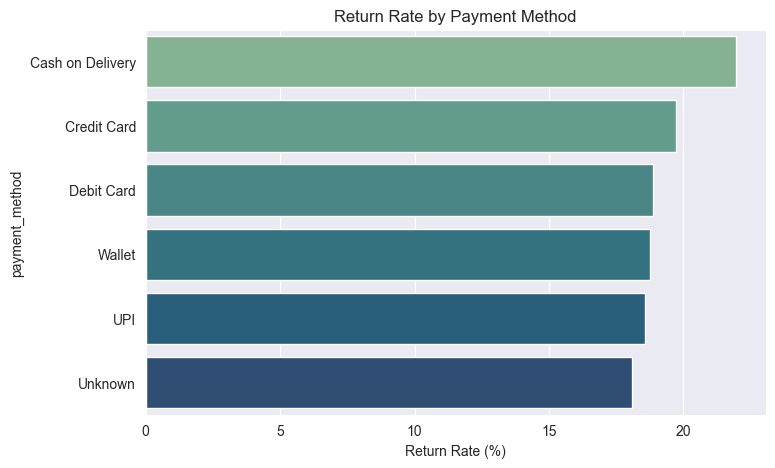

In [62]:
payment_return = (df.groupby('payment_method')['returned']
                     .apply(lambda x: (x == 'Yes').mean() * 100)
                     .sort_values(ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_return.values, y=payment_return.index, palette='crest')
plt.xlabel('Return Rate (%)')
plt.title('Return Rate by Payment Method')
plt.show()


In [63]:
contingency_pay = pd.crosstab(df['payment_method'], df['returned'])
chi2, p, dof, expected = chi2_contingency(contingency_pay)
print(f"Chi-square statistic: {chi2:.2f}  |  p-value: {p:.5f}")


Chi-square statistic: 16.64  |  p-value: 0.00523


**Interpretation:** Here, Cash on Delivery shows a notably higher return
rate with a significant p-value, this supports tightening COD eligibility rules (e.g., requiring partial
prepayment) for categories/customers with high past return rates.


## 12. Bivariate Analysis — Return Rate by Shipping Method

**Question we're asking:** Does faster/slower shipping correlate with returns independent of actual delay
(i.e., does the shipping *tier* chosen — Standard/Express/Next-Day — itself carry a different return
profile, perhaps reflecting different customer expectations)?

- customers paying for Express/Next-Day may have
higher expectations, so even a minor delay for these tiers might trigger a return more readily than the
same delay on a Standard order. Confirm this by cross-referencing with Section 6.



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40692\787990934.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shipping_return.index, y=shipping_return.values, palette='magma')


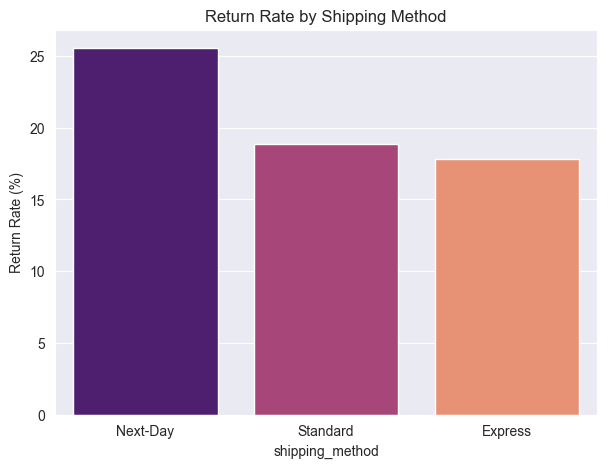

In [64]:
shipping_return = (df.groupby('shipping_method')['returned']
                      .apply(lambda x: (x == 'Yes').mean() * 100)
                      .sort_values(ascending=False))

plt.figure(figsize=(7, 5))
sns.barplot(x=shipping_return.index, y=shipping_return.values, palette='magma')
plt.ylabel('Return Rate (%)')
plt.title('Return Rate by Shipping Method')
plt.show()


In [65]:
contingency_ship = pd.crosstab(df['shipping_method'], df['returned'])
chi2, p, dof, expected = chi2_contingency(contingency_ship)
print(f"Chi-square statistic: {chi2:.2f}  |  p-value: {p:.5f}")


Chi-square statistic: 86.19  |  p-value: 0.00000


## 13. Bivariate Analysis — Customer Age Group vs Returns

**Question we're asking:** Do certain age demographics return products at meaningfully different rates?
Useful for tailoring customer communication/return policy messaging by segment.

**Statistical validation:** One-way ANOVA on `returned_flag` across `age_group` (treating it as comparing
group proportions) — supplemented with chi-square for the categorical view.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40692\2977906903.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_return.index, y=age_return.values, palette='cubehelix')


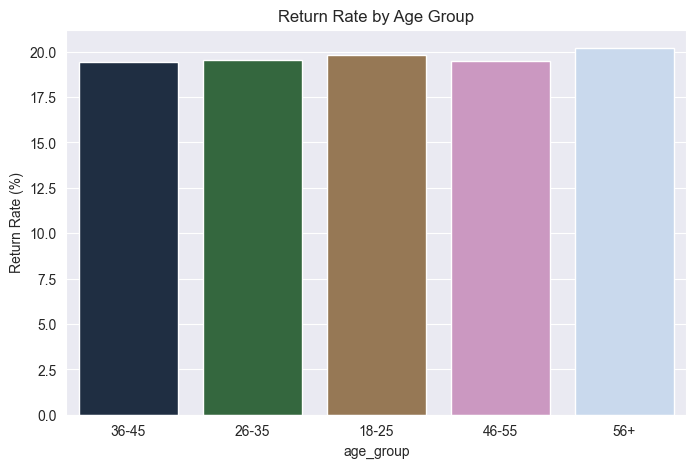

In [66]:
age_return = (df.groupby('age_group')['returned']
                .apply(lambda x: (x == 'Yes').mean() * 100)
                .reindex(df['age_group'].value_counts().index))

plt.figure(figsize=(8, 5))
sns.barplot(x=age_return.index, y=age_return.values, palette='cubehelix')
plt.ylabel('Return Rate (%)')
plt.title('Return Rate by Age Group')
plt.show()


In [67]:
contingency_age = pd.crosstab(df['age_group'], df['returned'])
chi2, p, dof, expected = chi2_contingency(contingency_age)
print(f"Chi-square statistic: {chi2:.2f}  |  p-value: {p:.5f}")


Chi-square statistic: 0.49  |  p-value: 0.97489


## 14. Multivariate Analysis — Category x Delivery Delay Heatmap

**Question we're asking:** Is the "delivery delay increases returns" effect (Section 6) consistent across
all product categories, or is it concentrated in a few (e.g., Electronics being especially delay-sensitive
while Groceries isn't)? This moves from a single-factor story to an actionable, targeted one.


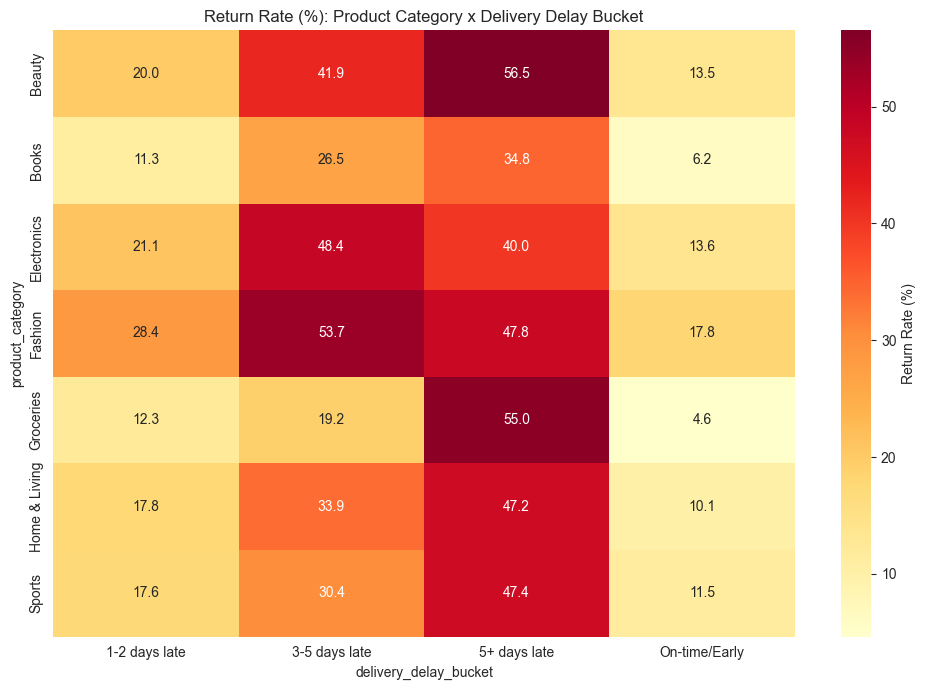

In [68]:
pivot = df.pivot_table(index='product_category', columns='delivery_delay_bucket',
                        values='returned_flag', aggfunc='mean') * 100

plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Return Rate (%)'})
plt.title('Return Rate (%): Product Category x Delivery Delay Bucket')
plt.tight_layout()
plt.show()


**Interpretation:** identify the single highest-intensity cell(s) in the
heatmap — that combination is your highest-priority intervention
target, since it concentrates the most return risk into one specific, addressable scenario.


## 15. Multivariate Analysis — Order Value by Return Status Across Categories

**Question we're asking:** When a return happens, is the business losing high-value or low-value orders?
This matters for prioritizing *financial* impact, not just *frequency* of returns.


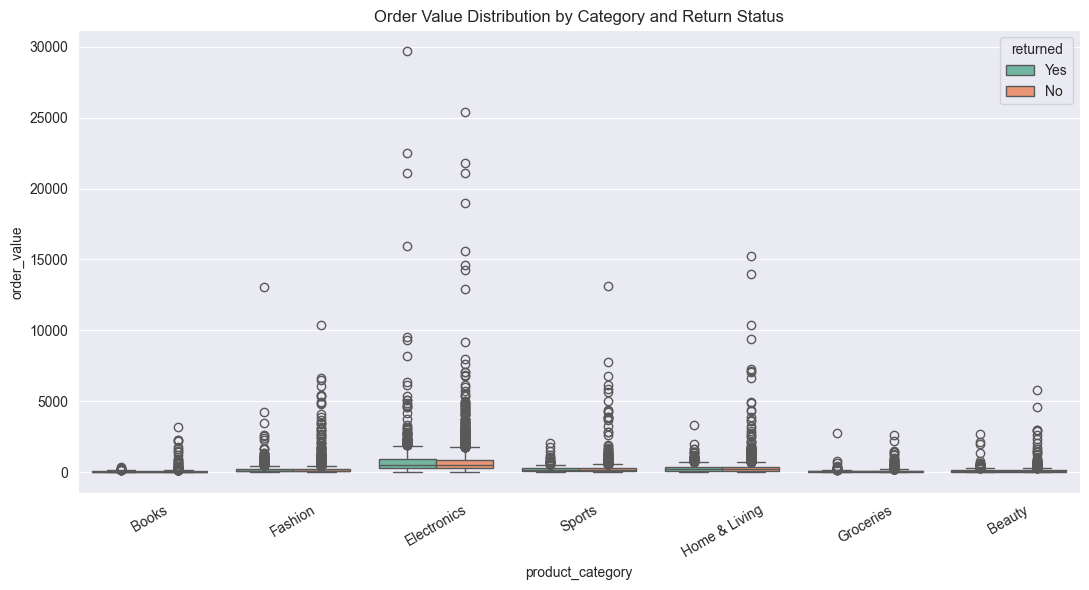

In [69]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=df, x='product_category', y='order_value', hue='returned', palette='Set2')
plt.xticks(rotation=30)
plt.title('Order Value Distribution by Category and Return Status')
plt.tight_layout()
plt.show()


In [70]:
revenue_at_risk = (df[df['returned'] == 'Yes']
                    .groupby('product_category')['order_value']
                    .sum()
                    .sort_values(ascending=False))
print("Total order value tied up in returns, by category:")
print(revenue_at_risk)


Total order value tied up in returns, by category:
product_category
Electronics      716294.42
Fashion          266963.93
Home & Living    154645.49
Sports            82588.85
Beauty            70144.27
Groceries         19839.54
Books             16697.68
Name: order_value, dtype: float64


**Interpretation:** cross-reference this with Section 5's return-rate-
by-category chart: a category can have a *lower* return rate but still represent a *larger* absolute
revenue risk if its order values are high. This distinction should directly shape the business
recommendations section (rate vs. revenue framing).


## 16. Return Reason Analysis

**Question we're asking:** Among orders that WERE returned, what's actually driving the return —
product defects, sizing issues, changed minds, or delivery problems? This is the most direct link to
*root cause*, useful for assigning ownership internally (QA team vs. logistics team vs. product listing
team).


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40692\4210561810.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='rocket')


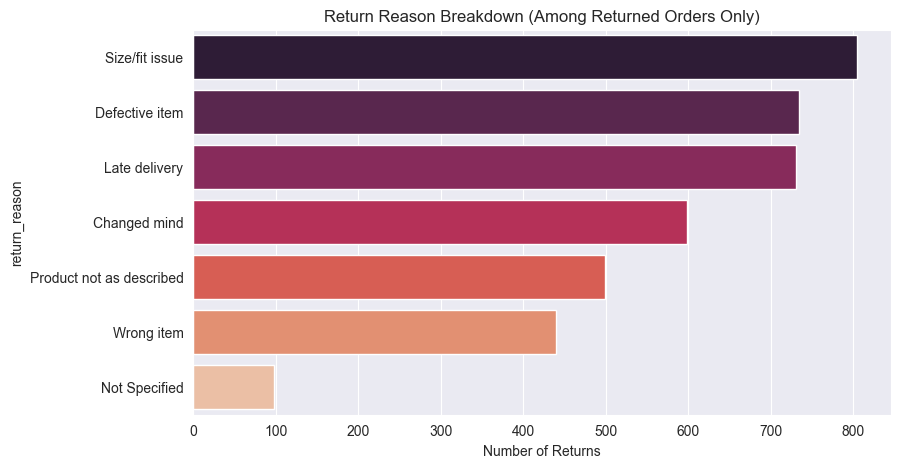

In [71]:
returned_only = df[df['returned'] == 'Yes']
reason_counts = returned_only['return_reason'].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='rocket')
plt.xlabel('Number of Returns')
plt.title('Return Reason Breakdown (Among Returned Orders Only)')
plt.show()


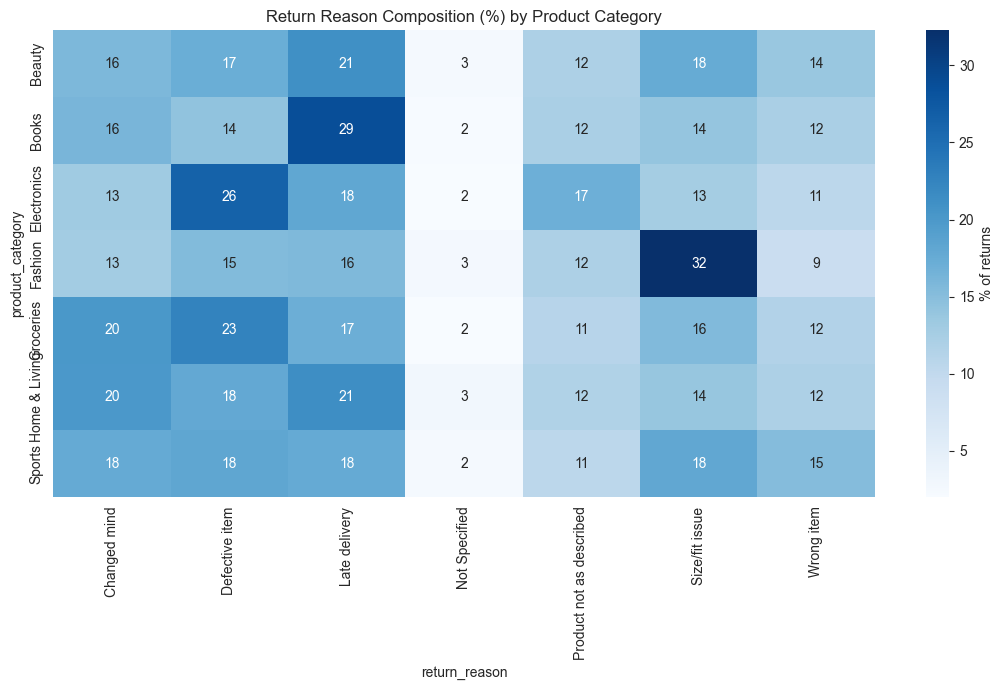

In [28]:
reason_by_category = pd.crosstab(returned_only['product_category'], returned_only['return_reason'], normalize='index') * 100
plt.figure(figsize=(11, 7))
sns.heatmap(reason_by_category, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': '% of returns'})
plt.title('Return Reason Composition (%) by Product Category')
plt.tight_layout()
plt.show()


**Interpretation:** the top 1-2 reasons overall, then check if
different categories have a *different dominant reason* (e.g., Fashion dominated by "Size/fit issue" vs.
Electronics dominated by "Defective item") — this determines whether the business needs one universal fix
or category-specific fixes.


## 17. Correlation Analysis — All Numeric Features

**Question we're asking:** Beyond the individual tests above, are there any strong relationships between
numeric features themselves (not just vs. returns) that we should know about before building any dashboard
KPI or later model — e.g., does `discount_percent` correlate with `product_price` in a way that could
confound the discount-returns relationship found in Section 8?


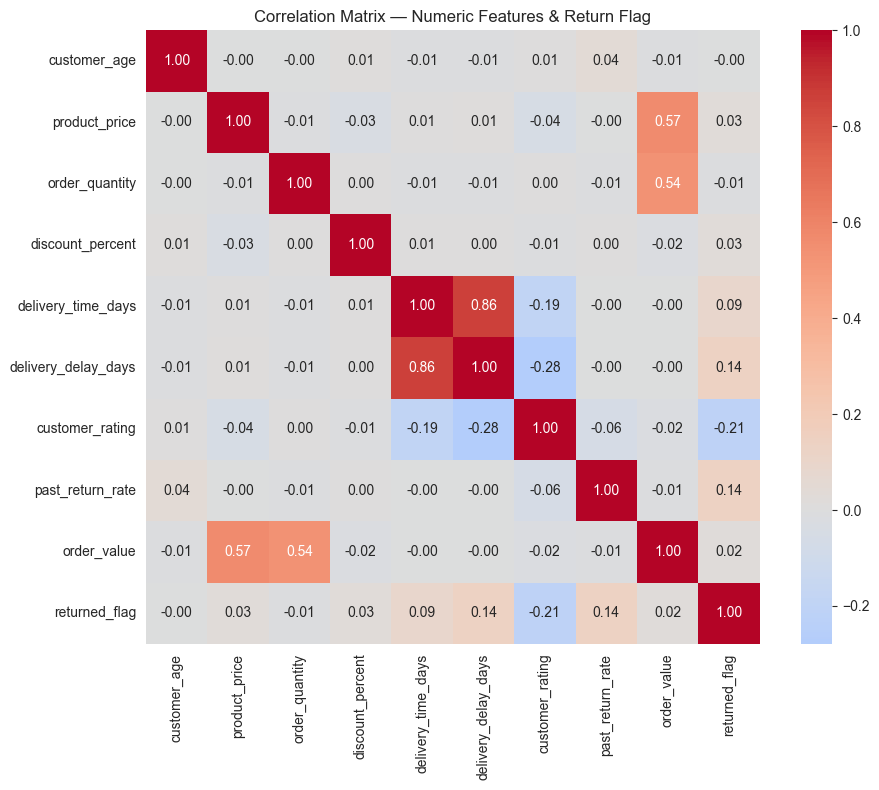

In [72]:
corr_cols = numeric_cols + ['returned_flag']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Numeric Features & Return Flag')
plt.tight_layout()
plt.show()


**Interpretation:** flag any correlation with `returned_flag` above
~0.15–0.2 as practically meaningful (returns data rarely shows very high single-variable correlations,
since returns are multi-causal). Also flag any strong correlation *between predictors themselves*
(e.g., `product_price` and `order_value`, which are mechanically related) — these shouldn't be treated as
two independent findings in the business report.


## 18. Summary of Statistically Validated Insights



| # | Finding | Statistical Support | Business Angle |
|---|---|---|---|
| 1 | Return rate varies significantly by product category | Chi-square, Section 5 | Prioritize QA/policy review for worst-performing categories |
| 2 | Delivery delay is associated with higher return rate | Chi-square, Section 6 | Logistics reliability investment could reduce returns |
| 3 | Past return rate strongly correlates with current return | Point-biserial correlation, Section 10 | Build a "high-risk returner" flag for proactive intervention |


**Next step:** These validated insights feed directly into the Tableau dashboard (as KPI cards and
filters) and the Business Recommendations report — each dashboard visual should map back to one of the
rows in this table so every chart has a statistically defensible story behind it.
